# PCA and t-SNE on bond-Holstein electron-density snapshots

This notebook reproduces panels (a)-(c) of Fig. 6 of the paper.
It loads DQMC-generated electron-density snapshots collected over a range of inverse temperatures $\beta$ at fixed dimensionless coupling $1/\lambda_{\text{bond}} = 2$ (i.e. $\alpha = 1.0$, $\omega_0 = 1$), and applies PCA followed by t-SNE.

The CSV layout assumed here is

    data/electron_densities_w<w>_a<alpha>_L<L>_csv-<sID>/electron_densities_w<w>_a<alpha>_L<L>-<sID>.csv

with shape $(N_{\text{samples}}, L^2 + 1)$: the first $L^2$ columns are one electron-density snapshot, the last column is the inverse temperature $\beta$ that the snapshot was generated at.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

# Repo-local plotting style
sys.path.insert(0, str(Path.cwd() / 'scripts'))
from plotting_style import apply_paper_style, fig_size

apply_paper_style()

## Parameters and data loading

In [2]:
w = 1.0          # phonon frequency
alpha = 1.0      # e-ph coupling (alpha=1.0 -> 1/lambda_bond = 2)
L = 12           # lattice linear size
sID = 7          # simulation ID -- selects which combined CSV to read

data_dir = Path('data')
sub = data_dir / f'electron_densities_w{w:.2f}_a{alpha:.4f}_L{L}_csv-{sID}'
combined = sub / f'electron_densities_w{w:.2f}_a{alpha:.4f}_L{L}-{sID}.csv'
print('Loading', combined)

arr = np.loadtxt(combined, delimiter=',')
N = L * L
X = arr[:, :N].astype(np.float64)         # (N_samples, L*L)
betas = arr[:, -1].astype(np.float64)     # per-snapshot inverse temperature

print(f'X.shape = {X.shape}')
print(f'distinct betas = {len(np.unique(betas))}, '
      f'beta in [{betas.min():.3f}, {betas.max():.3f}]')

Loading data/electron_densities_w1.00_a1.0000_L12_csv-7/electron_densities_w1.00_a1.0000_L12-7.csv
X.shape = (2100, 144)
distinct betas = 21, beta in [0.100, 1.100]


## A grid of representative snapshots

/var/folders/6s/vt08dqwx27j4lqbm05dnypvr0000gq/T/ipykernel_59172/946672691.py:11: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


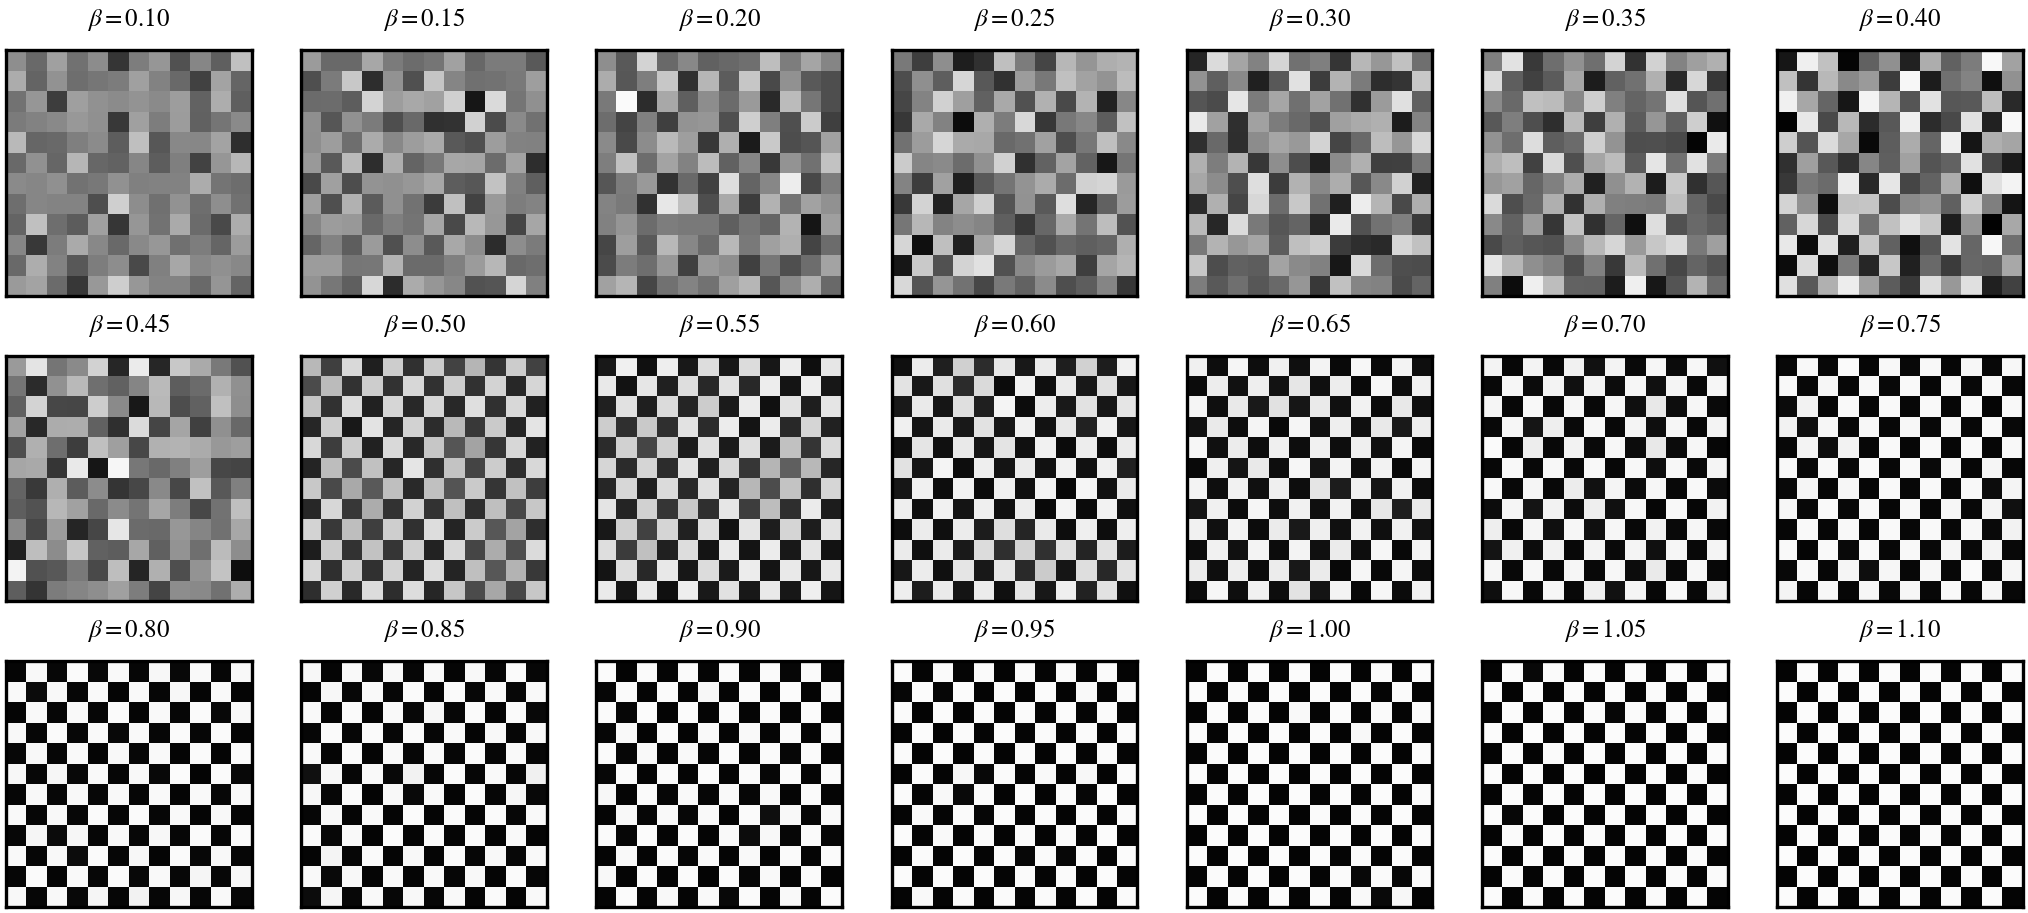

In [3]:
unique_betas = np.unique(betas)
samples_per_beta = (betas == unique_betas[0]).sum()

fig, axes = plt.subplots(3, 7, figsize=(7, 3.2))
for ax, b in zip(axes.flat, unique_betas[:axes.size]):
    mask = betas == b
    snapshot = X[mask][-1].reshape(L, L)
    ax.imshow(snapshot, cmap='binary', origin='lower', interpolation='nearest', vmin=0, vmax=2)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(fr'$\beta={b:.2f}$', fontsize=6)
fig.tight_layout()
plt.show()

## Principal component analysis

Center the snapshots, build the covariance matrix and diagonalize it. The leading principal component captures the staggered ($\pi,\pi$) CDW order.

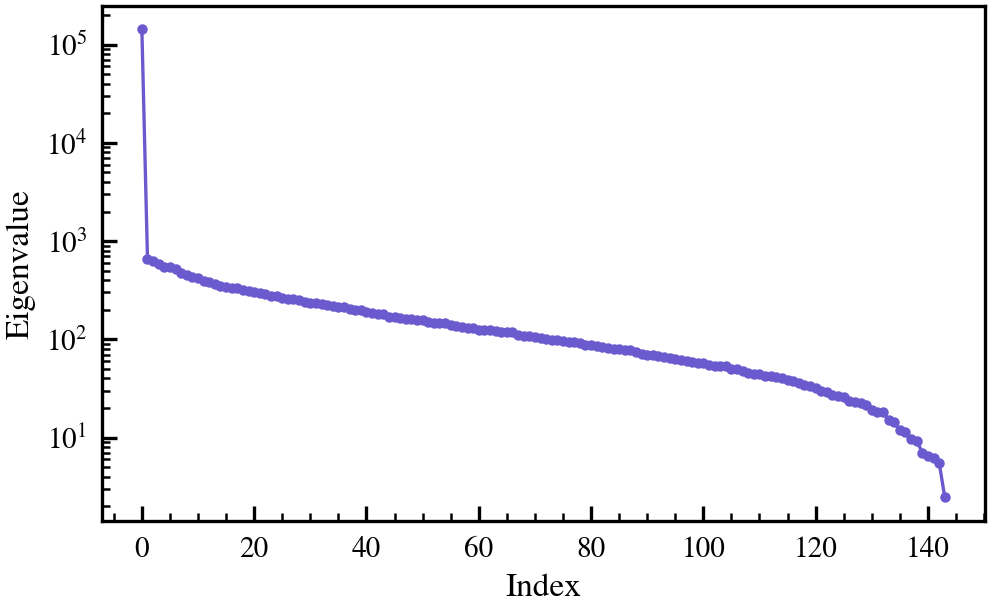

In [4]:
Xc = X - X.mean(axis=0, keepdims=True)
cov = Xc.T @ Xc
eigvals, eigvecs = np.linalg.eigh(cov)
order = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[order], eigvecs[:, order]

fig, ax = plt.subplots(figsize=fig_size(85))
ax.plot(eigvals, 'o-')
ax.set_yscale('log')
ax.set_xlabel('Index')
ax.set_ylabel('Eigenvalue')
plt.show()

P1 = Xc @ eigvecs[:, 0]
P2 = Xc @ eigvecs[:, 1]

### Fig. 6(a): scatter of the first two principal components

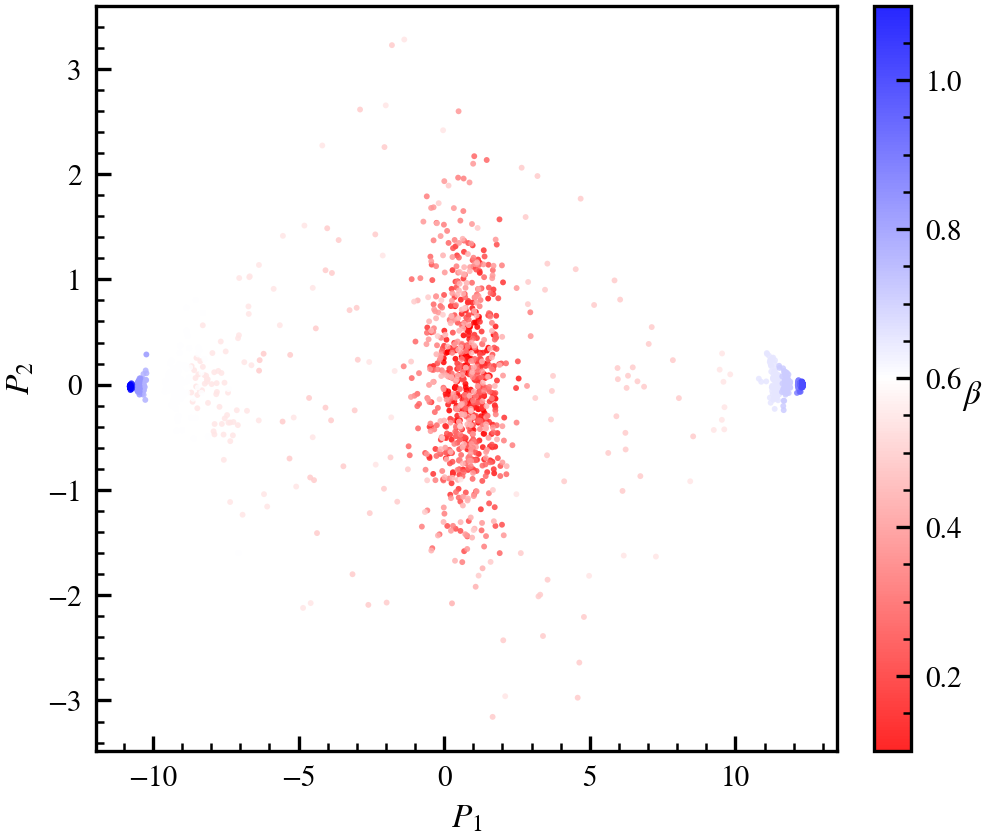

In [5]:
fig, ax = plt.subplots(figsize=fig_size(85, 0.85))
sc = ax.scatter(P1, P2, c=betas, cmap='bwr_r', s=2, alpha=0.85, linewidths=0)
plt.colorbar(sc, ax=ax).set_label(r'$\beta$', rotation=0)
ax.set_xlabel(r'$P_1$')
ax.set_ylabel(r'$P_2$')
plt.show()

### Fig. 6(b): $\langle |P_n|\rangle$ vs $\beta$

At the transition, $|P_1|$ jumps from a noise level to a plateau set by the lattice-scale CDW order parameter; $|P_2|$ peaks just above the transition.

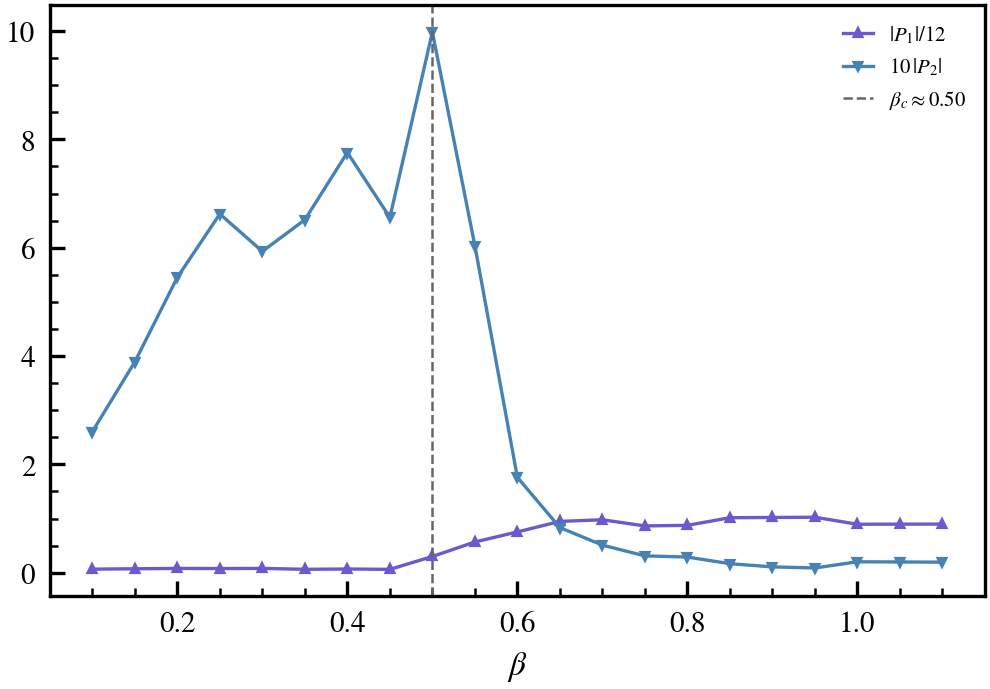

In [6]:
P1_avg = np.array([np.abs(P1[betas == b]).mean() for b in unique_betas])
P2_avg = np.array([np.abs(P2[betas == b]).mean() for b in unique_betas])

fig, ax = plt.subplots(figsize=fig_size(85, 0.7))
ax.plot(unique_betas, P1_avg / L, '-^', label=fr'$|P_1|/{L}$')
ax.plot(unique_betas, 10 * P2_avg, '-v', label=r'$10\,|P_2|$')

# Estimate beta_c as where |P1|/L crosses half its max
half = 0.5 * P1_avg.max() / L
crossings = np.where(np.diff(np.sign(P1_avg / L - half)))[0]
if len(crossings):
    bc = unique_betas[crossings[0]]
    ax.axvline(bc, color='0.4', linestyle='--', linewidth=0.6, label=fr'$\beta_c \approx {bc:.2f}$')

ax.set_xlabel(r'$\beta$')
ax.legend()
plt.show()

## t-SNE

A non-linear, neighbor-preserving embedding of the snapshots into 2D.

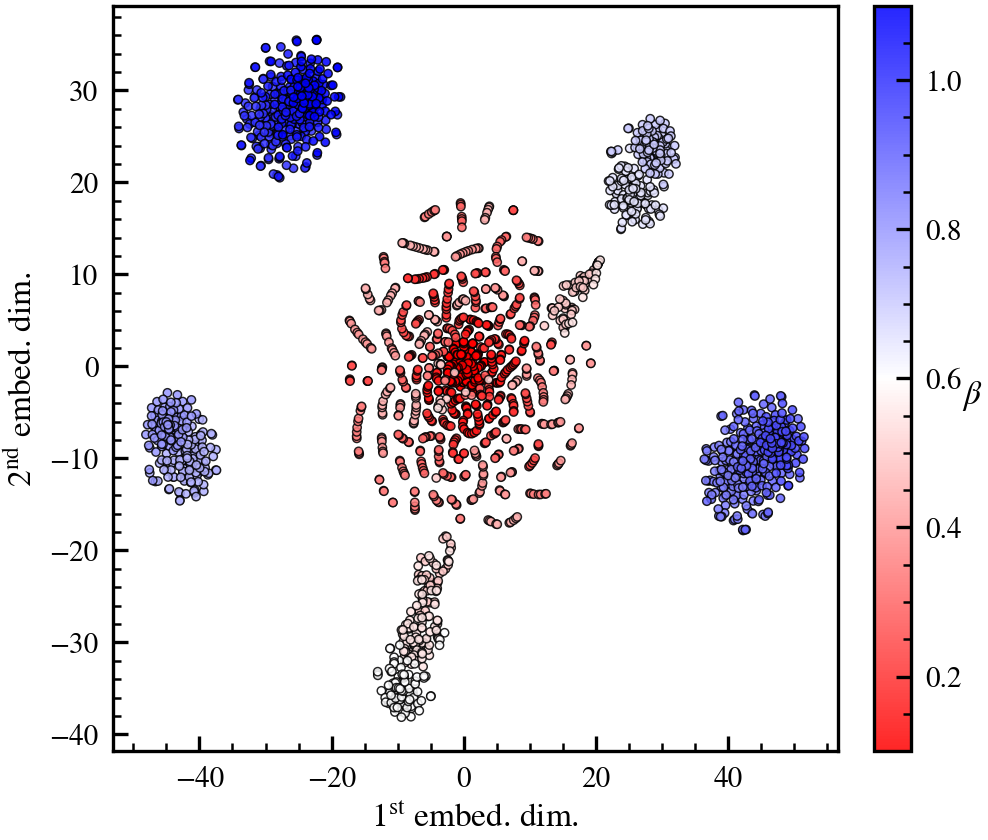

In [7]:
model = TSNE(perplexity=40, random_state=0, init="pca", learning_rate="auto")
emb = model.fit_transform(X)

fig, ax = plt.subplots(figsize=fig_size(85, 0.85))
sc = ax.scatter(emb[:, 0], emb[:, 1], c=betas, cmap='bwr_r',
                s=4, alpha=0.85, linewidths=0.35, edgecolors='black')
plt.colorbar(sc, ax=ax).set_label(r'$\beta$', rotation=0)
ax.set_xlabel(r'$1^{\mathrm{st}}$ embed. dim.')
ax.set_ylabel(r'$2^{\mathrm{nd}}$ embed. dim.')
plt.show()